In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.dates import DateFormatter, YearLocator, MonthLocator

import matplotlib.dates as mdates

from matplotlib.widgets import Button

import ipywidgets as widgets
from IPython.display import display


INPUT_FILE = Path("../data/final/ev_registrations_monthly_clean.csv")

df = pd.read_csv(INPUT_FILE)

In [3]:
# Convert month to datetime.
# Your final file uses "month" like "2024-01".
df["plot_date"] = pd.to_datetime(df["month"], errors="raise")

# Always sort time series before plotting.
df = df.sort_values("plot_date")

# Make sure numeric columns are actually numeric.
numeric_cols = [
    "total_new_registrations",
    "electric_new_registrations",
    "hybrid_new_registrations",
    "ev_share",
    "hybrid_share",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


def format_thousands(x, _):
    return f"{int(x):,}"


def format_percent(x, _):
    return f"{x * 100:.0f}%"


In [4]:
# -------------------------------------------------------------------
# Split historical estimates from observed monthly data
# -------------------------------------------------------------------

BREAK_DATE = pd.Timestamp("2026-01-01")

historical = df[df["plot_date"] < BREAK_DATE].copy()
observed_monthly = df[df["plot_date"] >= BREAK_DATE].copy()

# Extract year for historical aggregation.
historical["year"] = historical["plot_date"].dt.year

# Aggregate monthly-stretched historical rows back to one yearly point.
historical_yearly = (
    historical
    .groupby("year", as_index=False)
    .agg(
        total_new_registrations=("total_new_registrations", "mean"),
        electric_new_registrations=("electric_new_registrations", "mean"),
        hybrid_new_registrations=("hybrid_new_registrations", "mean"),
    )
)

# Use the middle of each year for plotting yearly estimates.
# This avoids visually implying that the yearly estimate belongs specifically to January.
historical_yearly["plot_date"] = pd.to_datetime(
    historical_yearly["year"].astype(str) + "-07-01"
)

# Recompute shares from yearly totals.
# This is better than averaging stretched monthly shares.
historical_yearly["ev_share"] = (
    historical_yearly["electric_new_registrations"]
    / historical_yearly["total_new_registrations"]
)

historical_yearly["hybrid_share"] = (
    historical_yearly["hybrid_new_registrations"]
    / historical_yearly["total_new_registrations"]
)

In [28]:
# ------------------------
# Add Trend Line EV Share 
# ------------------------

trend_data = pd.concat([
    historical_yearly[["plot_date", "ev_share"]],
    observed_monthly[["plot_date", "ev_share"]],
]).dropna()

trend_data["date_num"] = trend_data["plot_date"].map(pd.Timestamp.toordinal)

slope, intercept = np.polyfit(
    trend_data["date_num"],
    trend_data["ev_share"],
    1
)

trend_data["trend"] = slope * trend_data["date_num"] + intercept

baseline_2021 = historical_yearly.loc[
    historical_yearly["year"] == 2020, "ev_share"
].iloc[0]

policy_start = pd.Timestamp("2021-01-01")
policy_end = pd.Timestamp("2030-12-31")

policy_line = pd.DataFrame({
    "plot_date": [policy_start, policy_end],
    "ev_share": [baseline_2021, 1.0],
})

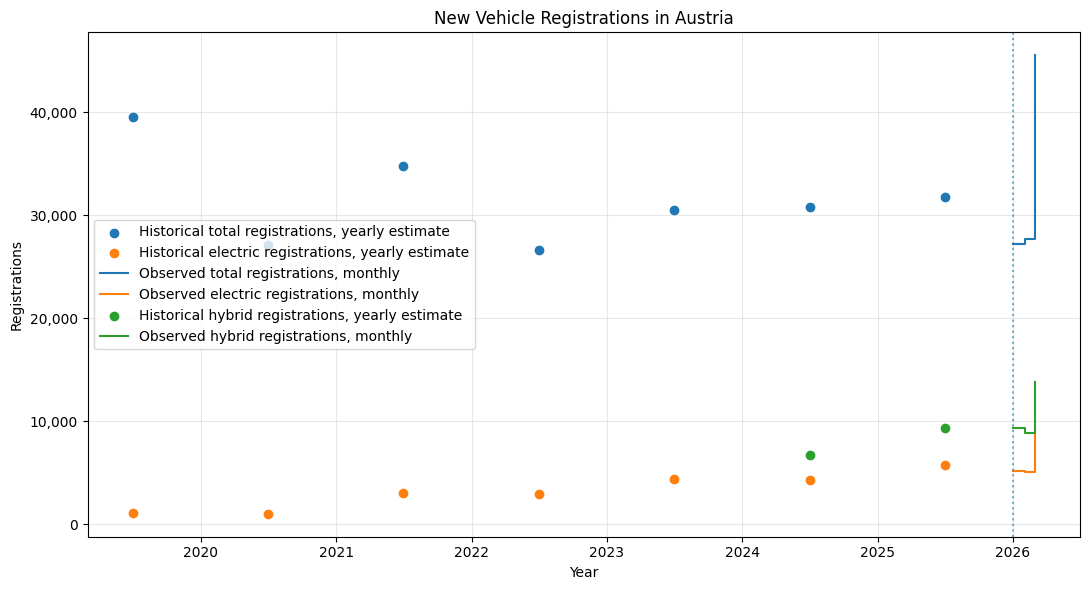

In [6]:
# -------------------------------------------------------------------
# Plot 1: registrations
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

# Historical estimated annual points.
ax.scatter(
    historical_yearly["plot_date"],
    historical_yearly["total_new_registrations"],
    label="Historical total registrations, yearly estimate",
)

ax.scatter(
    historical_yearly["plot_date"],
    historical_yearly["electric_new_registrations"],
    label="Historical electric registrations, yearly estimate",
)

# Observed monthly line from 2026 onward.
ax.step(
    observed_monthly["plot_date"],
    observed_monthly["total_new_registrations"],
    where="post",
    label="Observed total registrations, monthly",
)

ax.step(
    observed_monthly["plot_date"],
    observed_monthly["electric_new_registrations"],
    where="post",
    label="Observed electric registrations, monthly",
)

# Plot hybrid only if available.
if "hybrid_new_registrations" in df.columns and df["hybrid_new_registrations"].notna().any():
    ax.scatter(
        historical_yearly["plot_date"],
        historical_yearly["hybrid_new_registrations"],
        label="Historical hybrid registrations, yearly estimate",
    )

    ax.step(
        observed_monthly["plot_date"],
        observed_monthly["hybrid_new_registrations"],
        where="post",
        label="Observed hybrid registrations, monthly",
    )

# Optional visual break.
ax.axvline(
    BREAK_DATE,
    linestyle=":",
    alpha=0.6,
    label="_nolegend_",
)

ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter("%Y"))

ax.set_title("New Vehicle Registrations in Austria")
ax.set_xlabel("Year")
ax.set_ylabel("Registrations")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

history_view_toggle = widgets.ToggleButton(
    value=False,
    description="Focus on 2026+",
)

output = widgets.Output()

display(history_view_toggle, output)

DATE_PADDING = pd.DateOffset(months=3) # Adds some space to x-axis limits
FOCUS_VIEW_PADDING = pd.DateOffset(months=1) # Adds some space to x-axis limits
FULL_VIEW_PADDING = pd.DateOffset(months=3) # Adds some space to x-axis limits

EV_COLOR = "tab:blue"

observed_monthly["plot_date_mid"] = (
    observed_monthly["plot_date"] + pd.offsets.Day(14)
)

def plot_ev_share(focus_on_2026=False):
    with output:
        clear_output(wait=True)    
        
        # ---------
        # Create axes 
        # ----------

        if focus_on_2026:
            fig, (ax_hist, ax) = plt.subplots(
                     1,2,
                     figsize=(12, 6),
                     sharey = True,
                     gridspec_kw={"width_ratios": [1, 3]}
                )
        else:
            fig, ax = plt.subplots(figsize=(11,6))
        
        # Visual break between estimated historical data and observed monthly data.
        
        ax.axvline(
            BREAK_DATE,
            linestyle=":",
            alpha=0.6,
            label="_nolegend_",
        )

        # -------------
        # Historical EV Shares
        # -------------
         
        if focus_on_2026:
            ax_hist.scatter(
                 historical_yearly["plot_date"],
                 historical_yearly["ev_share"],
                 color = EV_COLOR,
                 label="Historical EV share, yearly estimate",
            )
        else:
            ax.scatter(
                historical_yearly["plot_date"],
                historical_yearly["ev_share"],
                color = EV_COLOR,
                label="Historical EV share, yearly estimate",
            )
        
        # ----------
        # Focus 2026 EV Share 
        # ----------

        ax.plot(
            observed_monthly["plot_date_mid"],
            observed_monthly["ev_share"],
            marker="o",
            color = EV_COLOR,
            label="Observed EV share, monthly",
        )

        # ---------
        # Policy Path
        # ---------

        if focus_on_2026:
            
            ax_hist.plot(
                policy_line["plot_date"],
                policy_line["ev_share"],
                linestyle="--",
                color = EV_COLOR,
                label="Policy path: 100% EV share by 2030",
            )

            ax.plot(
                policy_line["plot_date"],
                policy_line["ev_share"],
                linestyle="--",
                color = EV_COLOR,
                label="_nolegend_",
            )
        else: 
            ax.plot(
                policy_line["plot_date"],
                policy_line["ev_share"],
                linestyle="--",
                color = EV_COLOR,
                label="Policy path: 100% EV share by 2030",
            )

        # ---------
        # Axis Setup
        # ---------

        if focus_on_2026:

            # 2026 data 
            ax.set_xlim(
                BREAK_DATE,
                observed_monthly["plot_date_mid"].max() + FOCUS_VIEW_PADDING,
            )
            ax.xaxis.set_major_locator(MonthLocator(interval=1))
            ax.xaxis.set_major_formatter(DateFormatter("%b %Y"))

            # Historical Data
            ax_hist.set_xlim(
                 historical_yearly["plot_date"].min() - FULL_VIEW_PADDING,
                 historical_yearly["plot_date"].max() + FULL_VIEW_PADDING,
            )

            ax_hist.set_ylabel("Share")
            ax_hist.xaxis.set_major_locator(YearLocator())
            ax_hist.xaxis.set_major_formatter(DateFormatter("%Y"))
            ax_hist.grid(axis = "y", alpha=0.3)
            ax_hist.set_xlabel("Historical years")

            ax_hist.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.tick_params(labelleft=False)

            d = 0.015

            kwargs = dict(transform=ax_hist.transAxes, color="k", clip_on=False)
            ax_hist.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            ax_hist.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            kwargs = dict(transform=ax.transAxes, color="k", clip_on=False)
            ax.plot((-d, +d), (-d, +d), **kwargs)
            ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            
            history_view_toggle.description = "Show full history"

        else: 
      
            ax.set_xlim(
                historical_yearly["plot_date"].min() - DATE_PADDING,
                observed_monthly["plot_date"].max() + DATE_PADDING,
            )

            ax.xaxis.set_major_locator(YearLocator())
            ax.xaxis.set_major_formatter(DateFormatter("%Y"))
            ax.set_ylabel("Share")

            history_view_toggle.description = "Focus on 2026+"

        # ----------------
        # Legend
        # ----------------

        if focus_on_2026:
            handles_hist, labels_hist = ax_hist.get_legend_handles_labels()
            handles, labels = ax.get_legend_handles_labels()

            ax.legend(
                handles_hist + handles,
                labels_hist + labels,
                loc="lower right",
            )
        else:
            ax.legend()
        

        ax.yaxis.set_major_formatter(FuncFormatter(format_percent))
        ax.set_title("EV Share of New Registrations")
        ax.set_xlabel("Year")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


def update_plot(change):
    plot_ev_share(focus_on_2026=change["new"])


history_view_toggle.observe(update_plot, names="value")

# Draw the first version of the plot.
plot_ev_share(focus_on_2026=False)

ToggleButton(value=False, description='Focus on 2026+')

Output()

Plot for Klimadashboard

In [172]:
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, clear_output

from matplotlib.animation import FuncAnimation
import matplotlib.transforms as mtransforms

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# ------------------
# Color and style settings
# ------------------

KD_BG = "#18181B"          # bg-gray-900
KD_PANEL = "#27272A"       # bg-gray-800
KD_GRID = "#71717B"        # dark:bg-gray-500
KD_TEXT = "#F4F4F5"        # bg-gray-100 / light text
KD_MUTED = "#9F9FA9"       # bg-gray-400
KD_MOBILITY = "#F5AF4A"    # bg-mobility
KD_FONT = "Barlow"                          # Correct Font implement later
KD_FONT_CONDENSED = "Barlow Condensed"      # correct font implement later

EV_COLOR = KD_MOBILITY # Use Klimadashboard color as main color

plt.rcParams.update({
    "font.family": "sans-serif",            # Implement KD_FONT here later 
    "axes.facecolor": KD_BG,
    "figure.facecolor": KD_BG,
    "axes.edgecolor": KD_GRID,
    "axes.labelcolor": KD_TEXT,
    "xtick.color": KD_MUTED,
    "ytick.color": KD_MUTED,
    "text.color": KD_TEXT,
    "grid.color": KD_GRID,
    "grid.alpha": 0.25,
    "lines.linewidth": 1.8,
})

DATE_PADDING = pd.DateOffset(months=3) # Adds some space to x-axis limits
FOCUS_VIEW_PADDING = pd.DateOffset(months=1) # Adds some space to x-axis limits
FULL_VIEW_PADDING = pd.DateOffset(months=12) # Adds some space to x-axis limits

# Make data points for month appear in the middle of the month
observed_monthly["plot_date_mid"] = (
    observed_monthly["plot_date"] + pd.offsets.Day(14)
)

# ------------------
# Button Settings
# ------------------


zoom_40_toggle = widgets.ToggleButton(
    value=False,
    description="Zoom to 40%",
)

history_view_toggle = widgets.ToggleButton(
    value=False,
    description="Zoom to 2026+",
)

output = widgets.Output()

display(history_view_toggle, zoom_40_toggle, output)

# -----------------------
# Functions 
# -----------------------

def style_kd_axis(ax):
    '''
    Determine visual style, colors, grid, border and tick positioning of graph.
    '''
    ax.set_facecolor(KD_BG)

    # Makes axis around the graph/border disappear
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Makes 0 axis visible
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color(KD_GRID)
    ax.spines["bottom"].set_alpha(0.4)

    # Positions values of axis label (f.ex. 20%, 40 %)
    ax.tick_params(axis="x", colors=KD_MUTED, direction="in", length=6, pad=-6)
    ax.tick_params(axis="y", colors=KD_MUTED, length=0, pad=-6)

    for label in ax.get_xticklabels():
        label.set_verticalalignment("bottom")

    for label in ax.get_yticklabels():
        label.set_horizontalalignment("left")
        label.set_transform(
            label.get_transform()
            + mtransforms.ScaledTranslation(
                0, 8 / 72, ax.figure.dpi_scale_trans
            )
        )

    # Sets color of axis label
    ax.xaxis.label.set_color(KD_TEXT)
    ax.yaxis.label.set_color(KD_TEXT)

    # Sets color of grid
    ax.grid(color=KD_GRID, alpha=0.35, linewidth=1, axis="y")

def add_kd_header(fig, title):
    '''
    Adds and styles the header of the dashboard.
    '''
    fig.patch.set_facecolor(KD_BG)
    header_y = 0.88 # y-axis start
    header_x = 0.08 # x-axis start
    header_w = 1 # width
    header_h = 0.12 # header height

    header = patches.FancyBboxPatch(
        (header_x, header_y),
        header_w,
        header_h,
        boxstyle="round,pad=0.0,rounding_size=0.03",
        transform=fig.transFigure,
        facecolor=KD_MOBILITY,
        edgecolor="none",       
        zorder=10,
        clip_on=False,

    )
    fig.patches.append(header)

    # Overlay rectangle to remove bottom rounding
    bottom_fill = patches.Rectangle(
        (header_x, header_y),
        header_w,
        header_h - 0.03,
        transform=fig.transFigure,
        facecolor=KD_MOBILITY,
        edgecolor="none",
        zorder=11,
        clip_on=False,
    )
    fig.patches.append(bottom_fill)


    fig.text(
        header_x + header_x /2,
        header_y + header_h /2,
        title,
        color="white",
        fontsize=18,
        fontweight="bold",
        va="center",
        ha="left",
        zorder=12,
    )

    # Car icon on right side of header
    car_img = mpimg.imread("../data/media/car_trans.png")
    imagebox = OffsetImage(car_img, zoom=0.14)

    car_icon = AnnotationBbox(
        imagebox,
        (1.02, header_y + header_h / 2),
        xycoords=fig.transFigure,
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=12,
    )

    fig.add_artist(car_icon)

def configure_share_yaxis(ax, zoom_to_40=False, show_labels=True):

    '''
    Controls data scale and y-axis values, depending on the Zoom. 
    '''

    ymax = 0.4 if zoom_to_40 else 1.0

    ax.set_ylim(0, ymax)

    if zoom_to_40:
        ticks = [0, 0.1, 0.2, 0.3, 0.4] # y-axis only goes to 40 %
    else:
        ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

    ax.set_yticks(ticks)

    if show_labels:
        labels = [f"{t * 100:.0f}" for t in ticks]
        labels[-1] += "%"
        ax.set_yticklabels(labels)
    else:
        ax.set_yticklabels([])

def plot_ev_share(focus_on_2026=False, zoom_to_40=False):
    with output:
        clear_output(wait=True)

        if focus_on_2026:
            fig, (ax_hist, ax) = plt.subplots(
                1, 2,
                figsize=(12, 6),
                sharey=True,
                gridspec_kw={"width_ratios": [1, 3]}
            )
        else:
            fig, ax = plt.subplots(figsize=(11, 6))

            ax.axvline(
                BREAK_DATE,
                linestyle=":",
                alpha=0.6,
                label="_nolegend_",
            )

        add_kd_header(
            fig,
            "EV-Anteil Neuzulassungen vs. 2030-Ziel"
        )

         
        

        # Historical EV share
        if focus_on_2026:
            ax_hist.scatter(
                historical_yearly["plot_date"],
                historical_yearly["ev_share"],
                color=KD_MOBILITY,
                s=55,
                label="Historischer EV-Anteil, Jahresschätzung",
            )

            ax.scatter(
                historical_yearly["plot_date"],
                historical_yearly["ev_share"],
                color=KD_MOBILITY,
                s=55,
                label="_nolegend_",
            )

        else:
            ax.scatter(
                historical_yearly["plot_date"],
                historical_yearly["ev_share"],
                color=KD_MOBILITY,
                s=55,
                label="Historischer EV-Anteil, Jahresschätzung",
            )

        # Observed EV share
        ax.plot(
            observed_monthly["plot_date_mid"],
            observed_monthly["ev_share"],
            marker=None,
            markersize=6,
            linewidth=2.5,
            color=KD_MOBILITY,
            label="Beobachteter EV-Anteil, monatlich",
        )

        end_x = observed_monthly["plot_date_mid"].iloc[-1]
        end_y = observed_monthly["ev_share"].iloc[-1]

        blink_point, = ax.plot(
            [end_x], [end_y],
            marker="o",
            markersize=8,
            color=EV_COLOR,
            linestyle="None",
            label="_nolegend_",
            )   

        # Policy path
        if focus_on_2026:
            ax_hist.plot(
                policy_line["plot_date"],
                policy_line["ev_share"],
                linestyle=(0, (8, 6)),
                linewidth=2.2,
                color=KD_MOBILITY,
                alpha=0.5,
                label="Zielpfad: 100 % EV-Anteil bis 2030",
            )

            ax.plot(
                policy_line["plot_date"],
                policy_line["ev_share"],
                linestyle=(0, (8, 6)),
                linewidth=2.2,
                color=KD_MOBILITY,
                alpha=0.5,
                label="_nolegend_",
            )
        else:
            ax.plot(
                policy_line["plot_date"],
                policy_line["ev_share"],
                linestyle=(0, (12, 6)),
                linewidth=2.2,
                color=KD_MOBILITY,
                alpha=0.5,
                label="Zielpfad: 100 % EV-Anteil bis 2030",
            )

            if not focus_on_2026 and not zoom_to_40:
                policy_x = policy_line["plot_date"].iloc[-1]
                policy_y = policy_line["ev_share"].iloc[-1]

                ax.annotate(
                    "100 % EV-Anteil bis 2030",
                    xy=(policy_x, policy_y),
                    xytext=(-10, -10),
                    textcoords="offset points",
                    ha="right",
                    va="top",
                    color=EV_COLOR,
                    fontsize=11,
                    fontweight="bold",
                    alpha=0.5,
                )

        # Axis setup

        ymax = 0.4 if zoom_to_40 else 1.0

        if focus_on_2026:

            ax.set_xlim(
                historical_yearly["plot_date"].max(),
                observed_monthly["plot_date_mid"].max() + FOCUS_VIEW_PADDING,
            )
            ax.xaxis.set_major_locator(MonthLocator(interval=1))
            ax.xaxis.set_major_formatter(DateFormatter("%b %Y"))

            ax_hist.set_xlim(
                historical_yearly["plot_date"].min() - FULL_VIEW_PADDING,
                historical_yearly["plot_date"].max() - FOCUS_VIEW_PADDING,
            )
            ax_hist.xaxis.set_major_locator(YearLocator(base=2))
            ax_hist.xaxis.set_major_formatter(DateFormatter("%Y"))


            style_kd_axis(ax_hist)
            style_kd_axis(ax)

            ax_hist.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.tick_params(labelleft=False)

            d = 0.015
            kwargs = dict(transform=ax_hist.transAxes, color=KD_TEXT, clip_on=False)
            ax_hist.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            ax_hist.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            kwargs = dict(transform=ax.transAxes, color=KD_TEXT, clip_on=False)
            ax.plot((-d, +d), (-d, +d), **kwargs)
            ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)

            handles_hist, labels_hist = ax_hist.get_legend_handles_labels()
            handles, labels = ax.get_legend_handles_labels()

            legend = ax.legend(
                handles_hist + handles,
                labels_hist + labels,
                loc="upper right",
                facecolor=KD_BG,
                edgecolor=KD_GRID,
                labelcolor=KD_TEXT,
                framealpha=0.9,
            )

            history_view_toggle.description = "Show full history"

        else:

            ax.set_xlim(
                historical_yearly["plot_date"].min() - FULL_VIEW_PADDING,
                pd.Timestamp("2031-12-31"),
            )
            ax.xaxis.set_major_locator(YearLocator(base =2))
            ax.xaxis.set_major_formatter(DateFormatter("%Y"))

            style_kd_axis(ax)

            legend = ax.legend(
                loc="center right",
                facecolor=KD_BG,
                edgecolor=KD_GRID,
                labelcolor=KD_TEXT,
                framealpha=0.9,
            )

            if zoom_to_40:

                legend = ax.legend(
                loc="upper right",
                facecolor=KD_BG,
                edgecolor=KD_GRID,
                labelcolor=KD_TEXT,
                framealpha=0.9,
            )

            history_view_toggle.description = "Focus on 2026+"


        # --------------
        # Zoom to 40 %
        # --------------

        if zoom_to_40:
            zoom_40_toggle.description = " Zoom to 100%"
        else:
            zoom_40_toggle.description = "Zoom to 40%"


        if focus_on_2026:
            configure_share_yaxis(ax_hist, zoom_to_40, show_labels=True)
            #apply_share_axis(ax, zoom_to_40, show_labels=False)
        else:
            configure_share_yaxis(ax, zoom_to_40, show_labels=True)



        def blink(frame):
            blink_point.set_alpha(1.0 if frame % 2 == 0 else 0.2)
            return blink_point,

        anim = FuncAnimation(
            fig,
            blink,
            interval=500,
            blit=True,
            cache_frame_data=False, 
        )

        fig.anim = anim

        # --------------
        # Label Box for last observed point
        # --------------

        last_x = observed_monthly["plot_date_mid"].iloc[-1]
        last_y = observed_monthly["ev_share"].iloc[-1]
        
        last_start = observed_monthly["plot_date"].iloc[-1]
        last_end = last_start + pd.offsets.MonthEnd(0)

        last_period = (
            f"{last_start.strftime('%d.%m.%Y')} – "
            f"{last_end.strftime('%d.%m.%Y')}"
        )


        ax.annotate(
            f"{last_y:.1%} EV-Anteil im Zeitraum \n{last_period}",
            xy=(last_x, last_y),
            xytext=(12, -8),
            textcoords="offset points",
            ha="left",
            va="top",
            color=EV_COLOR,
            fontsize=11,
            fontweight="bold",
        )

        plt.subplots_adjust(top=0.82, bottom=0.13, left=0.08, right=0.97)
        plt.show()

def update_plot(change):
    plot_ev_share(
        focus_on_2026=history_view_toggle.value,
        zoom_to_40=zoom_40_toggle.value,
    )

history_view_toggle.observe(update_plot, names="value")
zoom_40_toggle.observe(update_plot, names="value")

# Draw the first version of the plot.
plot_ev_share(
    focus_on_2026=history_view_toggle.value,
    zoom_to_40=zoom_40_toggle.value,
    )


ToggleButton(value=False, description='Zoom to 2026+')

ToggleButton(value=False, description='Zoom to 40%')

Output()